In [4]:
import string 
import pandas as pd 
import numpy as np 

from nltk.corpus import stopwords 
from nltk.stem import SnowballStemmer

from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.model_selection import train_test_split

In [5]:
formspring_dataset = pd.read_csv("/kaggle/input/datasets/ubdelrhmanismal/fromspring/Formspring.csv")

formspring_dataset.head(10)

,text,answer
0,Q: what&#039;s your favorite song? :D<br>A: I ...,No
1,Q: <3<br>A: </3 ? haha jk! <33,No
2,Q: &quot;hey angel you duh sexy&quot;<br>A: R...,No
3,Q: (:<br>A: ;(,No
4,Q: ******************MEOWWW*******************...,No
5,Q: any makeup tips? i suck at doing my makeup ...,No
6,Q: Apriiiiiiiiiiiill!!! I miss uuuu! It&#039;s...,No
7,Q: Are you a morning or night person?<br>A: Ni...,No
8,Q: are you a trusting person?<br>A: alreadi an...,No
9,Q: are you a trusting person?<br>A: Yes veryy ...,No


In [6]:
formspring_dataset.shape

(13147, 2)

In [7]:
formspring_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13147 entries, 0 to 13146
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    13147 non-null  object
 1   answer  13147 non-null  object
dtypes: object(2)
memory usage: 205.6+ KB


In [8]:
formspring_dataset.describe()

,text,answer
count,13147,13147
unique,13144,2
top,Q: Wait. Are you Cheyenne? I sent a request to...,No
freq,3,12295


In [9]:
formspring_dataset.isnull().sum()

text      0
answer    0
dtype: int64

In [10]:
formspring_dataset["answer"].value_counts()

answer
No     12295
Yes      852
Name: count, dtype: int64

In [11]:
formspring_text_features = formspring_dataset["text"].copy()
tfid_vectorizer = TfidfVectorizer(encoding ="english")
formspring_features = tfid_vectorizer.fit_transform(formspring_text_features)
print(formspring_text_features)

0        Q: what&#039;s your favorite song? :D<br>A: I ...
1                           Q: <3<br>A: </3 ? haha jk! <33
2        Q: &quot;hey angel  you duh sexy&quot;<br>A: R...
3                                           Q: (:<br>A: ;(
4        Q: ******************MEOWWW*******************...
                               ...                        
13142    Q: Youre at a party and your friend who drove ...
13143    Q: Youu2019re awesome :] Give yourself a compl...
13144    Q: Yu play with yurself ?<br>A: all the time. ...
13145    Q: yukk beer is disgusting. i can only drink i...
13146    Q: if i told u den it would make it all the le...
Name: text, Length: 13147, dtype: object


In [12]:
print(formspring_features)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 254506 stored elements and shape (13147, 18775)>
  Coords	Values
  (0, 17947)	0.15984947496542218
  (0, 4)	0.21166783975854714
  (0, 18614)	0.16445580974678042
  (0, 6020)	0.5901629635353193
  (0, 15130)	0.3373860496444202
  (0, 2417)	0.06294444269439241
  (0, 9775)	0.19038717708585326
  (0, 16688)	0.26377533756496274
  (0, 10321)	0.30068023170403524
  (0, 15135)	0.43794630875263
  (0, 16619)	0.13666204960704684
  (0, 7574)	0.17265193864975523
  (1, 2417)	0.10517467075209345
  (1, 7324)	0.3741534117644445
  (1, 8965)	0.6831137869399059
  (1, 212)	0.6183066126040023
  (2, 2417)	0.05634780356239197
  (2, 7324)	0.20045437554062448
  (2, 13327)	0.5094343603709673
  (2, 7765)	0.2886547397744486
  (2, 1044)	0.4381590967996309
  (2, 18600)	0.0865259371250384
  (2, 5157)	0.42483910836891375
  (2, 14472)	0.3371973861965128
  (2, 13501)	0.2132496484348259
  :	:
  (13145, 5128)	0.22992749038686963
  (13145, 4804)	0.3182924140169115
  (

In [13]:
saved_formspring_df = pd.DataFrame(formspring_text_features)
saved_formspring_df.to_csv("Formspring Text Features.csv")

**encoding answer **


In [14]:
from sklearn.preprocessing import LabelEncoder

column = ["answer"]
label_encoder = LabelEncoder()

for i in column : 
    formspring_dataset[i] = label_encoder.fit_transform(formspring_dataset[i])


print(formspring_dataset.dtypes)

text      object
answer     int64
dtype: object


In [15]:
formspring_dataset.head(10)

,text,answer
0,Q: what&#039;s your favorite song? :D<br>A: I ...,0
1,Q: <3<br>A: </3 ? haha jk! <33,0
2,Q: &quot;hey angel you duh sexy&quot;<br>A: R...,0
3,Q: (:<br>A: ;(,0
4,Q: ******************MEOWWW*******************...,0
5,Q: any makeup tips? i suck at doing my makeup ...,0
6,Q: Apriiiiiiiiiiiill!!! I miss uuuu! It&#039;s...,0
7,Q: Are you a morning or night person?<br>A: Ni...,0
8,Q: are you a trusting person?<br>A: alreadi an...,0
9,Q: are you a trusting person?<br>A: Yes veryy ...,0


In [16]:
formspring_features_train, formspring_features_test, formspring_labels_train,formspring_labels_test = train_test_split(
    formspring_features,
    formspring_dataset["answer"],
    test_size = 0.3,
    random_state = 0
    
)

In [17]:
print("Features Train from the Datset - Formspring .csv")
print('-'* 53)

print(formspring_features_train)

Features Train from the Datset - Formspring .csv
-----------------------------------------------------
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 179600 stored elements and shape (9202, 18775)>
  Coords	Values
  (0, 2417)	0.03687841403308925
  (0, 16619)	0.16013739838761806
  (0, 7324)	0.39357910984477595
  (0, 18600)	0.0566293472356025
  (0, 10481)	0.1079458602559176
  (0, 1263)	0.21824086264372766
  (0, 15058)	0.11432439183090222
  (0, 9080)	0.13019336689436078
  (0, 17724)	0.2132879511941004
  (0, 14193)	0.15565001789621416
  (0, 16329)	0.1016387305988438
  (0, 11838)	0.21197072495543287
  (0, 16332)	0.16661218265063113
  (0, 12949)	0.17856962737993035
  (0, 11398)	0.3768049392329972
  (0, 12344)	0.14621839945084314
  (0, 15147)	0.4725221963728408
  (0, 1921)	0.17728453519423656
  (0, 16008)	0.23885011990465854
  (0, 16312)	0.25658762882146335
  (1, 18614)	0.07722238405488448
  (1, 2417)	0.029556389253449264
  (1, 16619)	0.06417145917029331
  (1, 7324)	0.105145314

In [24]:
from sklearn.model_selection import GridSearchCV

from sklearn.svm import (SVR, SVC)
from sklearn.naive_bayes import MultinomialNB

from sklearn.linear_model import (Ridge, RidgeClassifier, SGDRegressor, SGDClassifier, LogisticRegression)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from matplotlib import style
import matplotlib.pyplot as plt
%matplotlib inline
import warnings 
warnings.filterwarnings("ignore")


In [30]:
#metric scores : C-support Vector Classfication #
svc = SVC(kernel = "sigmoid" , gamma = 1.0)

svc.fit(formspring_features_train, formspring_labels_train)

svc_prediction= svc.predict(formspring_features_test)
svc_accuracy_score = accuracy_score(formspring_labels_test, svc_prediction)
svc_precision_score = precision_score(formspring_labels_test, svc_prediction)
svc_recall_score = recall_score(formspring_labels_test, svc_prediction)
svc_f1_score = f1_score(formspring_labels_test, svc_prediction)
        


In [39]:
#metric scores : multinomialNB
mnb = MultinomialNB(alpha = 0.2)
mnb.fit(formspring_features_train, formspring_labels_train)
mnb_prediction = mnb.predict(formspring_features_test)
mnb_precision_score = precision_score(formspring_labels_test,mnb_prediction)
mnb_accuracy_score = accuracy_score(formspring_labels_test,mnb_prediction)
mnb_recall_score = recall_score(formspring_labels_test, mnb_prediction)
mnb_f1_score = f1_score(formspring_labels_test, mnb_prediction)

In [40]:
# metric Scores : DecidionTreeClassifier 
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier()
dtc.fit(formspring_features_train, formspring_labels_train)
dtc_prediction = dtc.predict(formspring_features_test)
dtc_accuracy_score = accuracy_score(formspring_labels_test,dtc_prediction)
dtc_precision_score = precision_score(formspring_labels_test, dtc_prediction)
dtc_recall_score = recall_score(formspring_labels_test,dtc_prediction)
dtc_f1_score = f1_score(formspring_labels_test,dtc_prediction)

In [43]:
print(f"""________Evaluation for: C-Support Vector Classification________
Model Type:         {svc}
Accuracy Score:     {svc_accuracy_score:%}
Precision Score:    {svc_precision_score:%}
Recall Score:       {svc_recall_score:%}
F1-Score:           {svc_f1_score:%}

C-Support Vector Classification - Confusion Matrix:
{confusion_matrix(formspring_labels_test, svc_prediction)}

C-Support Vector Classification - Classification Report:
{classification_report(formspring_labels_test, svc_prediction)}
----------------------------THE END----------------------------
______Evaluation for: Multinomial Naive Bayes Classifier_______
Model Type:         {mnb}
Accuracy Score:     {mnb_accuracy_score:%}
Precision Score:    {mnb_precision_score:%}
Recall Score:       {mnb_recall_score:%}
F1-Score:           {mnb_f1_score:%}

C-Support Vector Classification - Confusion Matrix:
{confusion_matrix(formspring_labels_test, mnb_prediction)}

C-Support Vector Classification - Classification Report:
{classification_report(formspring_labels_test, mnb_prediction)}
----------------------------THE END----------------------------
___________Evaluation for: Decision Tree Classifier____________
Model Type:         {dtc}
Accuracy Score:     {dtc_accuracy_score:%}
Precision Score:    {dtc_precision_score:%}
Recall Score:       {dtc_recall_score:%}
F1-Score:           {dtc_f1_score:%}

C-Support Vector Classification - Confusion Matrix:
{confusion_matrix(formspring_labels_test, dtc_prediction)}

C-Support Vector Classification - Classification Report:
{classification_report(formspring_labels_test, dtc_prediction)}
----------------------------THE END----------------------------""")

________Evaluation for: C-Support Vector Classification________
Model Type:         SVC(gamma=1.0, kernel='sigmoid')
Accuracy Score:     94.879594%
Precision Score:    85.882353%
Recall Score:       27.756654%
F1-Score:           41.954023%

C-Support Vector Classification - Confusion Matrix:
[[3670   12]
 [ 190   73]]

C-Support Vector Classification - Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      3682
           1       0.86      0.28      0.42       263

    accuracy                           0.95      3945
   macro avg       0.90      0.64      0.70      3945
weighted avg       0.94      0.95      0.94      3945

----------------------------THE END----------------------------
______Evaluation for: Multinomial Naive Bayes Classifier_______
Model Type:         MultinomialNB(alpha=0.2)
Accuracy Score:     93.434728%
Precision Score:    53.333333%
Recall Score:       12.167300%
F1-Score:           19.81424

findfont: Font family 'Arial Black' not found.
findfont: Font family 'Arial Black' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Arial Black' not found.
findfont: Font family 'Arial Black' not found.
findfont: Font family 'Arial Black' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Arial Black' not found.
findfont: Font family 'Arial Black' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Arial Black' not found.
findfont: Font family 'Arial Black' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Arial Black' not found.
findfont: Font family 'Arial Black' not found.
findfont: Font family 'Arial Black' not found.
findfont: Font family 'Times New Roman' not found.


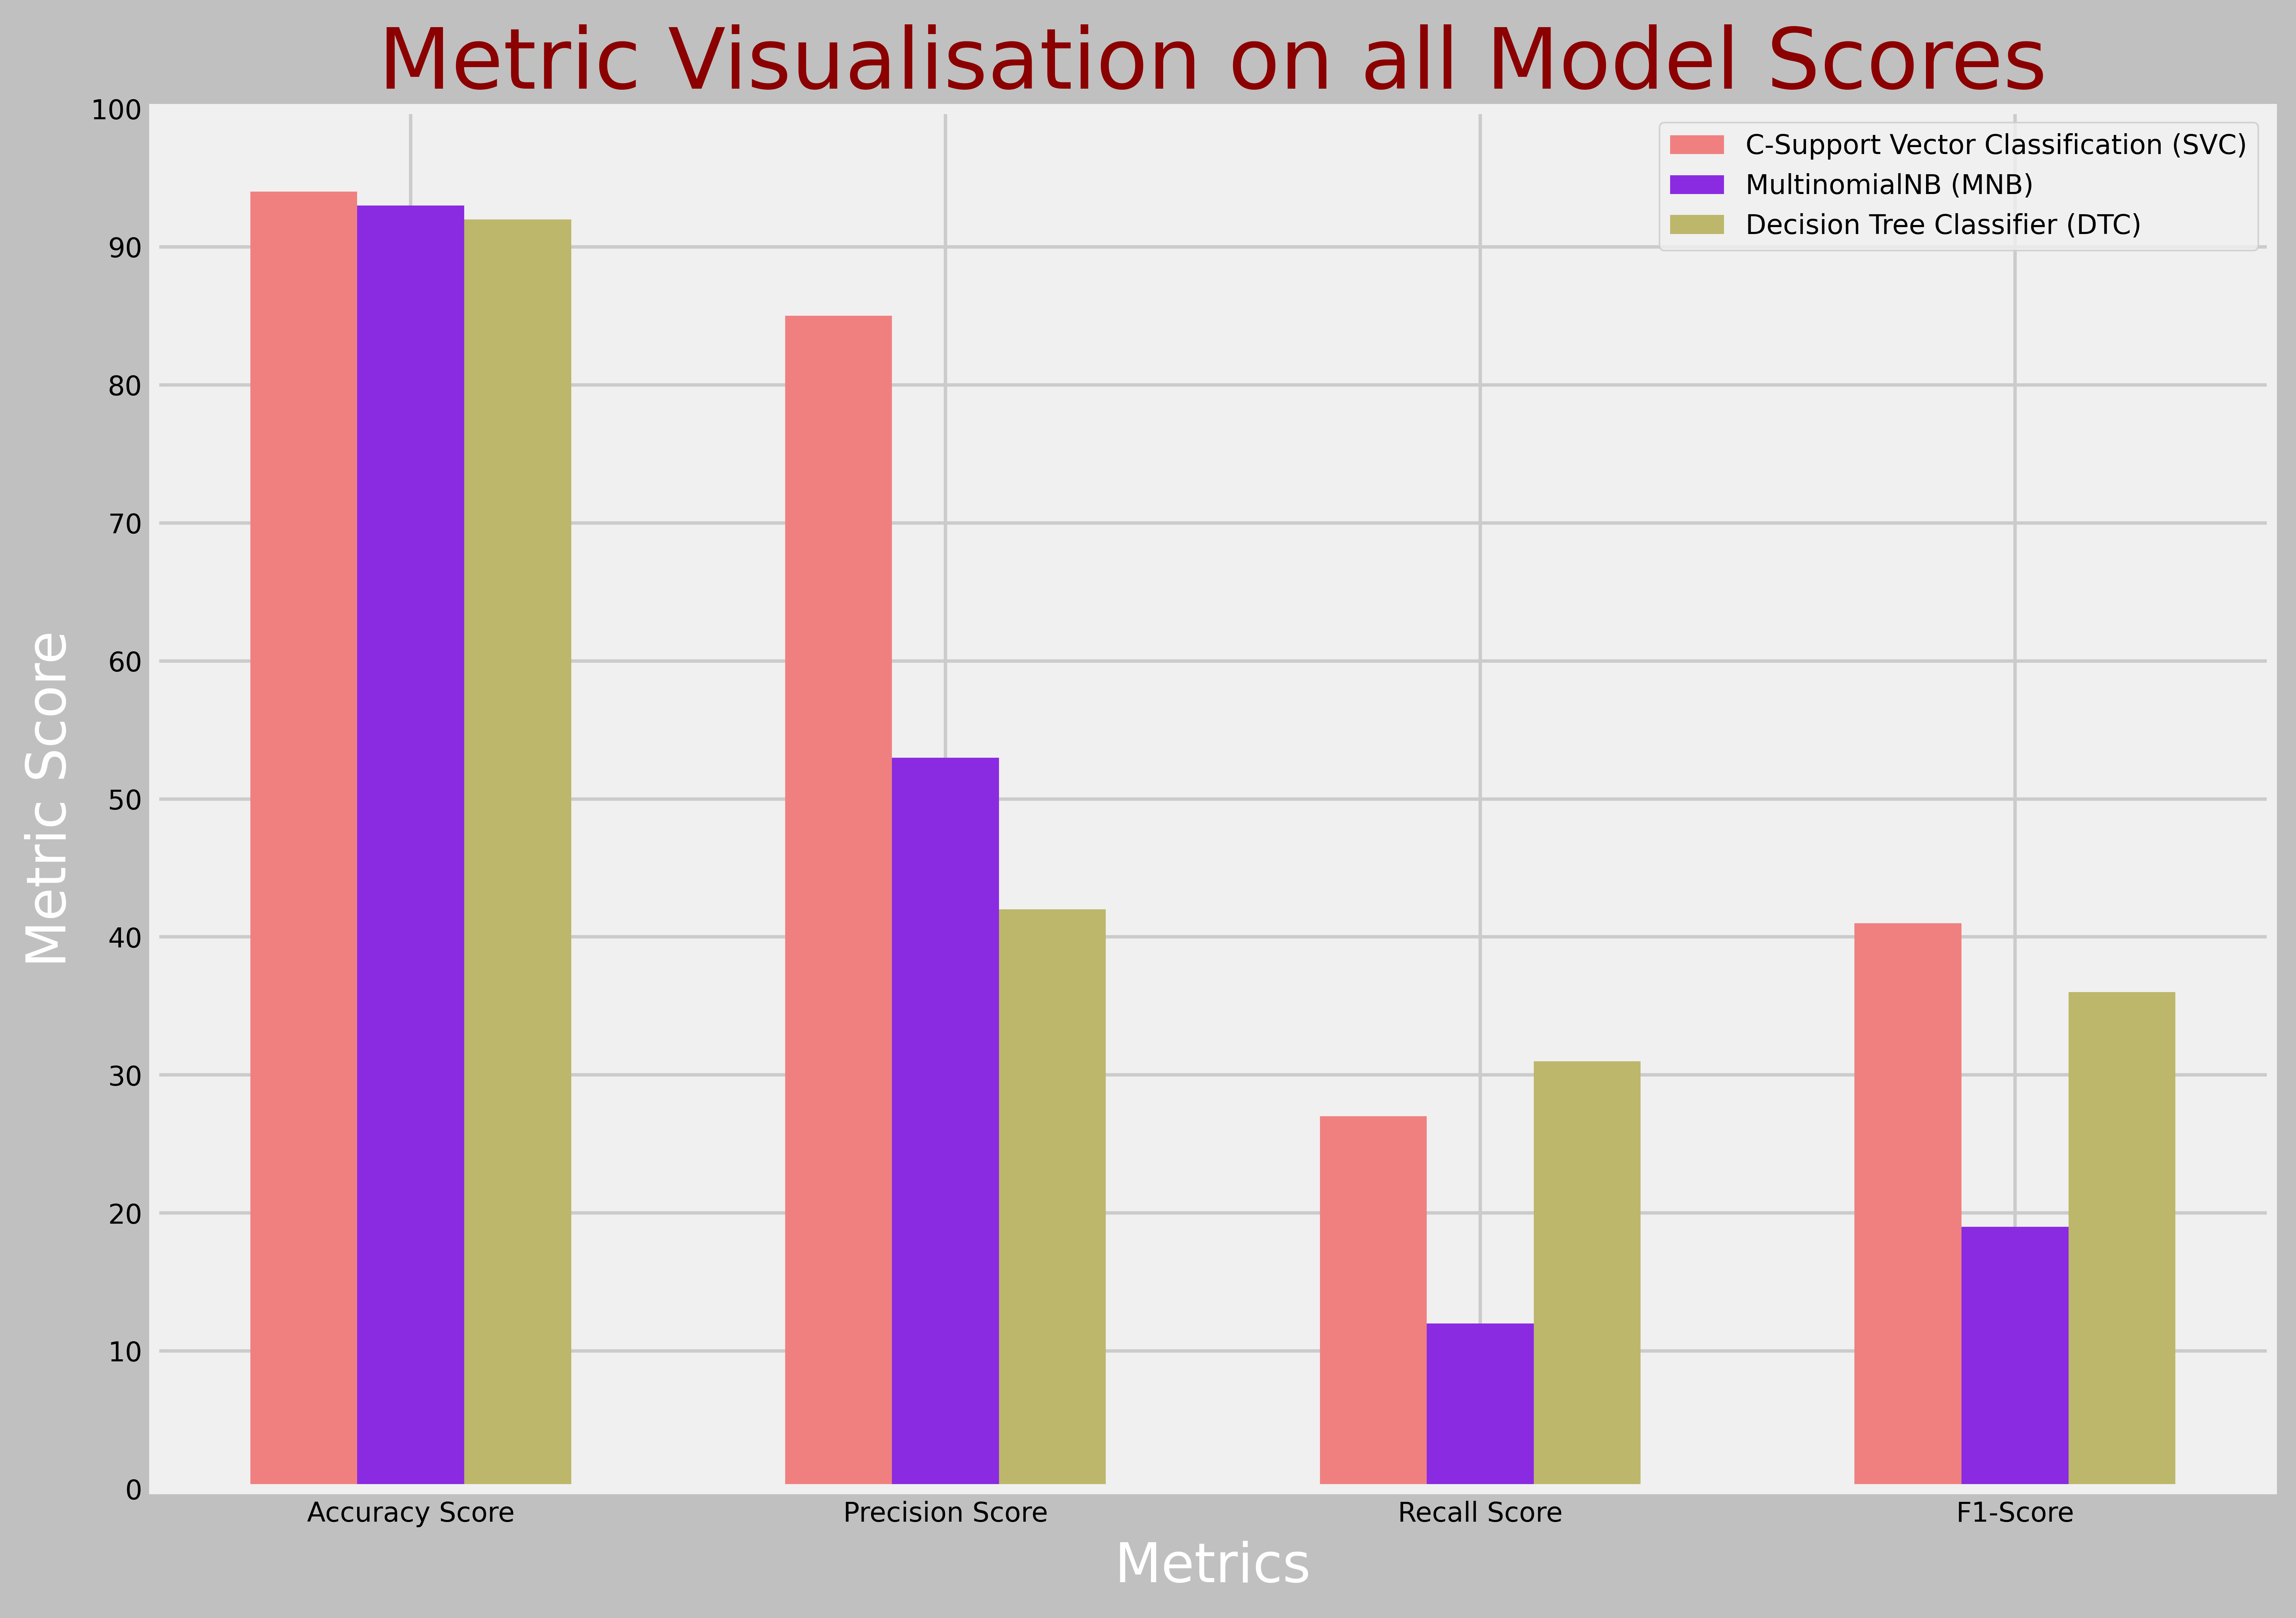

End of the Workshop 02.


In [44]:
svc_scores = (
    int(svc_accuracy_score * 100), 
    int(svc_precision_score * 100), 
    int(svc_recall_score * 100), 
    int(svc_f1_score * 100)
)
mnb_scores = (
    int(mnb_accuracy_score * 100), 
    int(mnb_precision_score * 100), 
    int(mnb_recall_score * 100), 
    int(mnb_f1_score * 100)
)

dtc_scores = (
    int(dtc_accuracy_score * 100), 
    int(dtc_precision_score * 100), 
    int(dtc_recall_score * 100), 
    int(dtc_f1_score * 100)
)

x_grid = ["Accuracy Score", "Precision Score", "Recall Score", "F1-Score"]
y_grid = [value for value in range(0, 105, 10)]
xpos = np.arange(len(x_grid))
bar_width = .2

style.use("fivethirtyeight")
plt.rcParams['font.size'] = 8
plt.figure(figsize=(10, 7), dpi=700, facecolor="silver")
plt.title(  # Add a title to the graph (specify font parameters with the Argument: fontdict).
    "Metric Visualisation on all Model Scores", 
    fontdict={
        "fontname": "Times New Roman", 
        "fontsize": 25
    }, 
    color="darkred"
)
plt.bar(xpos, svc_scores, width=bar_width, color="lightcoral", label="C-Support Vector Classification (SVC)")
plt.bar((xpos + 0.2), mnb_scores, width=bar_width, color="blueviolet", label="MultinomialNB (MNB)")
plt.bar((xpos + 0.4), dtc_scores, width=bar_width, color="darkkhaki", label="Decision Tree Classifier (DTC)")
plt.xlabel(  # Just like the "Function: plt.title()", this gives a title to the X-Axis.
    "Metrics", 
    fontdict={
        "fontname": "Arial Black", 
        "fontsize": 16
    }, 
    color="white"
)
plt.xticks((xpos + 0.2), x_grid)
plt.ylabel(  # Just like the "Function: plt.title()", this gives a title to the Y-Axis.
    "Metric Score", 
    fontdict={
        "fontname": "Arial Black", 
        "fontsize": 16
    }, 
    color="white"
)
plt.yticks(y_grid)
plt.legend()
plt.savefig("Workshop 2 - Graph.jpg", dpi=700)
plt.show()

print("End of the Workshop 02.")
